# Titanic Survival Prediction

This notebook builds a **neural network** to predict survival on the Titanic. We use a **leak-free pipeline**: split first, then impute, encode, and scale using **training data only**.

## 1. Load data & explore

Load the dataset and inspect columns and shape.

In [1]:
import pandas as pd
df = pd.read_csv('titanic.csv')

### 1.1 Exploratory data analysis (EDA)

Charts below: target balance, survival by key features, and correlation of numeric predictors.

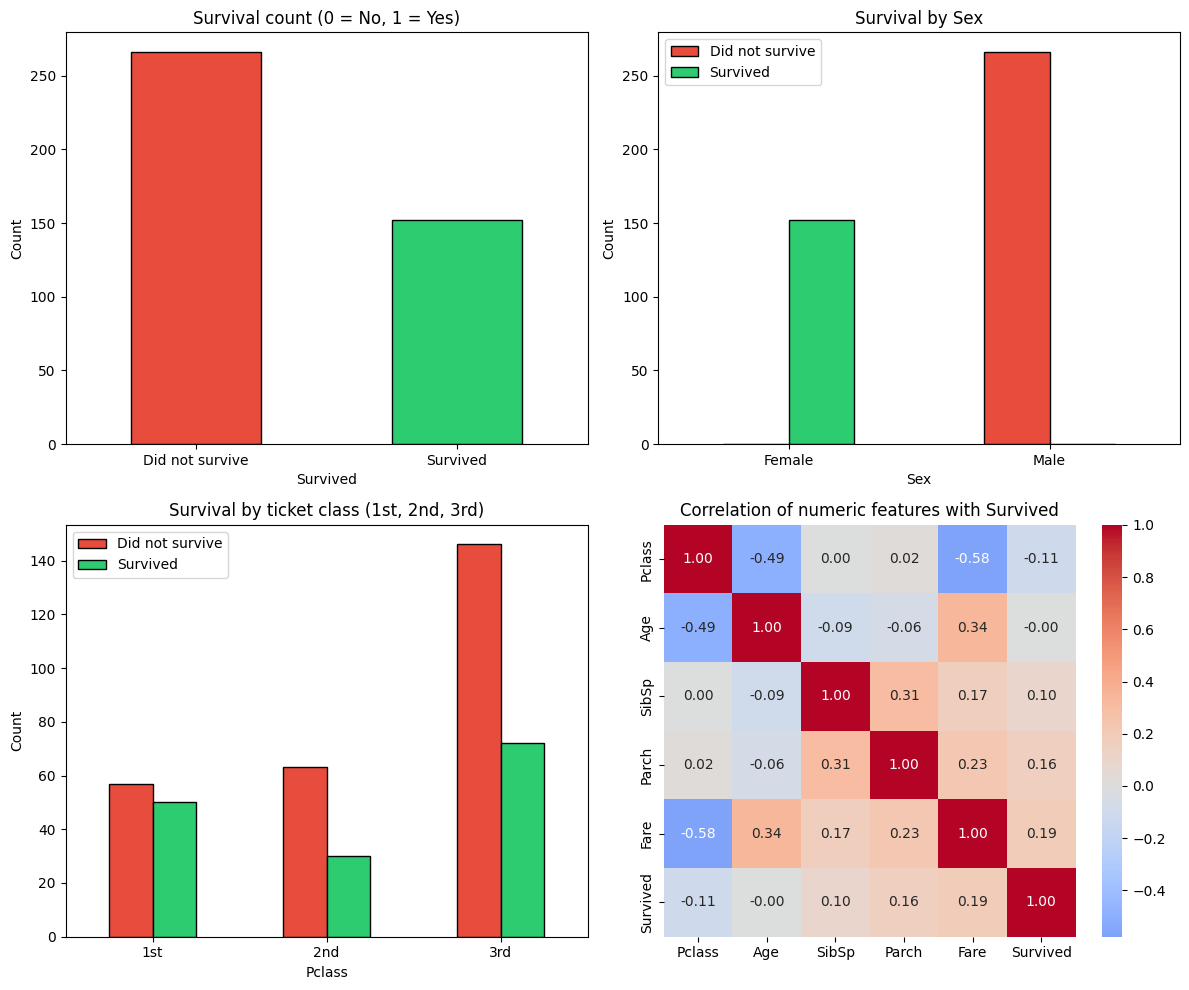

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Target balance
df['Survived'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0, 0].set_title('Survival count (0 = No, 1 = Yes)')
axes[0, 0].set_xticklabels(['Did not survive', 'Survived'], rotation=0)
axes[0, 0].set_ylabel('Count')

# 2. Survival by Sex
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', ax=axes[0, 1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0, 1].set_title('Survival by Sex')
axes[0, 1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0, 1].legend(['Did not survive', 'Survived'])
axes[0, 1].set_ylabel('Count')

# 3. Survival by Pclass
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar', ax=axes[1, 0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1, 0].set_title('Survival by ticket class (1st, 2nd, 3rd)')
axes[1, 0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
axes[1, 0].legend(['Did not survive', 'Survived'])
axes[1, 0].set_ylabel('Count')

# 4. Correlation heatmap (numeric features used in model)
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1], square=True)
axes[1, 1].set_title('Correlation of numeric features with Survived')

plt.tight_layout()
plt.show()

In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## 2. Define features and target (no leakage)

We take only the columns we need and **do not** impute or encode yet. Imputation and encoding will be done **after** the train/test split using **training data only**, to avoid data leakage.

In [4]:
import pandas as pd

# Use .copy() to avoid SettingWithCopyWarning.
# Do NOT impute or encode on full data — that leaks test info. We'll do it after the split.
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
y = df['Survived'].copy()
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S
414,1,female,39.0,0,0,108.9000,C
415,3,male,38.5,0,0,7.2500,S
416,3,male,NaN,0,0,8.0500,S


### 2.1 Missing values

Count of missing values per feature. These will be filled after the split using **train** statistics only.

In [5]:
X.isna().sum()


Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

## 3. Train–test split

Split into 70% train and 30% test **before** any imputation or encoding. This keeps the test set completely unseen during preprocessing.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

## 4. Preprocessing (impute & encode from train only)

- **Impute** missing Age, Fare, Embarked using **medians/mode from the training set**.
- **One-hot encode** categoricals (Sex, Embarked) on train, then align test to the same columns (no extra categories from test).

In [7]:
# Impute and encode using TRAIN only (no data leakage)
age_median = X_train['Age'].median()
fare_median = X_train['Fare'].median()
embarked_mode = X_train['Embarked'].mode()[0]

X_train = X_train.copy()
X_test = X_test.copy()
X_train['Age'] = X_train['Age'].fillna(age_median)
X_train['Fare'] = X_train['Fare'].fillna(fare_median)
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Age'] = X_test['Age'].fillna(age_median)
X_test['Fare'] = X_test['Fare'].fillna(fare_median)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

# One-hot encode: fit on train, align test to same columns
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## 5. Scale features

Fit `StandardScaler` on the **training set** only, then transform both train and test. Puts all features on a similar scale for the neural network.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Final safety check
import numpy as np
print(np.isnan(X_train).any(), np.isinf(X_train).any())

False False


### 5.1 Scaled training data (preview)

Scaled feature matrix passed to the neural network (zero mean, unit variance per feature).

In [9]:
X_train

array([[-1.47596812,  0.42426237, -0.50269793, ...,  0.78310898,
        -0.35082321, -1.31490378],
       [ 0.8727114 , -0.1818675 , -0.50269793, ...,  0.78310898,
         2.85043856, -1.31490378],
       [-1.47596812,  2.46995069,  0.5766241 , ..., -1.27696148,
        -0.35082321,  0.76051192],
       ...,
       [-1.47596812,  1.18192471, -0.50269793, ...,  0.78310898,
        -0.35082321, -1.31490378],
       [-0.30162836, -0.48493244, -0.50269793, ...,  0.78310898,
        -0.35082321,  0.76051192],
       [ 0.8727114 , -0.1818675 , -0.50269793, ...,  0.78310898,
         2.85043856, -1.31490378]], shape=(292, 8))

## 6. Neural network model

A small **feedforward network**: two hidden layers (16 and 8 units, ReLU) and a single output with **sigmoid** for binary classification (survived vs not).

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 7. Train the model

We train for 50 epochs with a 20% validation split from the training data. The `history` object stores loss and accuracy per epoch for plotting.

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4378 - loss: 0.7711 - val_accuracy: 0.4237 - val_loss: 0.7945
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4979 - loss: 0.7413 - val_accuracy: 0.5085 - val_loss: 0.7684
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5837 - loss: 0.7158 - val_accuracy: 0.5593 - val_loss: 0.7442
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6395 - loss: 0.6909 - val_accuracy: 0.6271 - val_loss: 0.7194
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7210 - loss: 0.6662 - val_accuracy: 0.6780 - val_loss: 0.6933
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7597 - loss: 0.6396 - val_accuracy: 0.7119 - val_loss: 0.6635
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7682 - loss: 0.6096 - val_accuracy: 0.7119 - val_loss: 0.6289
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8155 - loss: 0.5746 - val_accuracy: 0.7797 - val_los

## Neural Network Architecture for Titanic Survival Prediction

In [13]:
import plotly.graph_objects as go
import numpy as np
from IPython.display import HTML, display

# Architecture: 8 → 16 → 8 → 1 (from model)
layer_sizes = [8, 16, 8, 1]
layer_labels = ['Input (8)', 'Hidden 1 (16, ReLU)', 'Hidden 2 (8, ReLU)', 'Output (1, sigmoid)']

def get_node_positions(sizes):
    positions = []  # (layer_idx, y) per node
    for i, n in enumerate(sizes):
        y = np.linspace(1, -1, n) if n > 1 else [0]
        for yi in y:
            positions.append((i, yi))
    return positions

def get_edges(sizes):
    edges = []
    idx = 0
    for i in range(len(sizes) - 1):
        start_idx = idx
        end_idx = idx + sizes[i]
        next_start = end_idx
        next_end = next_start + sizes[i + 1]
        for a in range(start_idx, end_idx):
            for b in range(next_start, next_end):
                edges.append((a, b))
        idx = end_idx
    return edges

positions = get_node_positions(layer_sizes)
edges = get_edges(layer_sizes)

# Build edge traces (line from node A to node B)
edge_x, edge_y = [], []
for a, b in edges:
    x0, y0 = positions[a][0], positions[a][1]
    x1, y1 = positions[b][0], positions[b][1]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

node_x = [p[0] for p in positions]
node_y = [p[1] for p in positions]
# Color by layer
node_color = []
idx = 0
for i, n in enumerate(layer_sizes):
    for _ in range(n):
        node_color.append(i)
    idx += n

fig = go.Figure()
fig.add_trace(go.Scatter(x=edge_x, y=edge_y, mode='lines', line=dict(color='rgba(100,100,100,0.25)', width=0.8), hoverinfo='skip'))
fig.add_trace(go.Scatter(x=node_x, y=node_y, mode='markers', marker=dict(size=12, color=node_color, colorscale='Viridis', line=dict(width=1, color='white')),
                         hovertext=[layer_labels[c] for c in node_color], hoverinfo='text'))

fig.update_layout(title='Neural network architecture (TensorFlow Playground–style)', showlegend=False,
                  xaxis=dict(showgrid=False, zeroline=False, showticklabels=True, tickvals=[0,1,2,3],
                             ticktext=['Input', 'Hidden 1', 'Hidden 2', 'Output']),
                  yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                  height=450, margin=dict(b=60), plot_bgcolor='white')
display(HTML(fig.to_html(include_plotlyjs='cdn')))

### 7.1 Training history (loss & accuracy)

Curves below show how **training** and **validation** loss/accuracy change over epochs. Validation metrics tell us how well the model generalizes; if validation loss starts rising while training loss falls, that suggests overfitting.

In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, display

epochs = list(range(1, len(history.history['accuracy']) + 1))
fig = make_subplots(rows=1, cols=2, subplot_titles=('Loss over epochs', 'Accuracy over epochs'))

fig.add_trace(go.Scatter(x=epochs, y=history.history['loss'], name='Train loss', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs, y=history.history['val_loss'], name='Validation loss', line=dict(color='red', dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs, y=history.history['accuracy'], name='Train accuracy', line=dict(color='blue')), row=1, col=2)
fig.add_trace(go.Scatter(x=epochs, y=history.history['val_accuracy'], name='Validation accuracy', line=dict(color='red', dash='dash')), row=1, col=2)

fig.update_xaxes(title_text='Epoch', row=1, col=1)
fig.update_xaxes(title_text='Epoch', row=1, col=2)
fig.update_yaxes(title_text='Loss', row=1, col=1)
fig.update_yaxes(title_text='Accuracy', row=1, col=2)
fig.update_layout(height=400, hovermode='x unified')
display(HTML(fig.to_html(include_plotlyjs='cdn')))

## 8. Evaluate on test set

Report loss and accuracy on the **held-out test set** (never used for training or preprocessing).

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0050
Test Accuracy: 1.0


In [16]:
from sklearn.metrics import accuracy_score

# Convert probabilities → 0/1 labels
y_pred = (model.predict(X_test) > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Neural Network Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Neural Network Accuracy: 1.0


### 8.1 Confusion matrix & ROC curve

- **Confusion matrix**: counts of true positives, false positives, true negatives, false negatives. Diagonal = correct predictions.
- **ROC curve**: true positive rate vs false positive rate at different thresholds. **AUC** = area under the curve (1.0 = perfect classifier).

In [17]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, display

y_pred_proba = model.predict(X_test).ravel()
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Confusion matrix', 'ROC curve'),
                    column_widths=[0.45, 0.55])

fig.add_trace(go.Heatmap(z=cm, x=['Predicted 0', 'Predicted 1'], y=['Actual 0', 'Actual 1'],
                         colorscale='Blues', text=cm, texttemplate='%{text}', textfont={"size": 14}, showscale=True),
              row=1, col=1)
fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f'ROC (AUC = {roc_auc:.3f})', line=dict(color='darkorange', width=2)), row=1, col=2)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], name='Random', line=dict(color='navy', width=2, dash='dash')), row=1, col=2)

fig.update_xaxes(title_text='False Positive Rate', row=1, col=2, range=[0, 1])
fig.update_yaxes(title_text='True Positive Rate', row=1, col=2, range=[0, 1.05])
fig.update_layout(height=450, hovermode='x unified')
display(HTML(fig.to_html(include_plotlyjs='cdn')))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [18]:
y_pred = model.predict(X_test)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 


array([[3.4328091e-03],
       [9.9614662e-01],
       [2.0319277e-03],
       [1.5075327e-03],
       [9.9809504e-01],
       [1.2508273e-03],
       [9.9529719e-01],
       [6.3343038e-04],
       [9.9218577e-01],
       [1.1733678e-03],
       [2.6012242e-03],
       [9.9927598e-01],
       [9.9425811e-01],
       [9.9746752e-01],
       [1.1733678e-03],
       [2.8441139e-03],
       [9.9508971e-01],
       [6.8150926e-04],
       [3.7470988e-03],
       [1.4376189e-03],
       [1.0965799e-03],
       [8.5682626e-04],
       [9.8915523e-01],
       [1.3371476e-03],
       [9.9665207e-01],
       [9.8768836e-01],
       [9.9536085e-01],
       [1.4575702e-03],
       [6.1506629e-02],
       [1.3371476e-03],
       [1.7789692e-03],
       [9.9249578e-01],
       [9.9506074e-01],
       [1.1733678e-03],
       [9.9367249e-01],
       [1.2872152e-03],
       [9.9152821e-01],
       [3.1469089e-03],
       [9.9659288e-01],
       [2.8444991e-02],
       [9.9152821e-01],
       [9.976146